In [119]:
# Import necessary libraries

# evaluate bagging ensemble for regression
import numpy as np
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import pandas as pd 
import itertools
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
%matplotlib inline

In [68]:
# Read the dataset
df = pd.read_csv("airquality.csv",index_col = 0)

In [88]:
# # Take a quick look at the data
df = df[df.Ozone.notna()]
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
6,28.0,NaN,14.9,66,5,6


In [125]:
# # Assign "x" column as the predictor variable and "y" as the
x,y = df['Ozone'].values,df['Temp'].values
x,y = list(zip(*sorted(zip(x,y))))
x,y = np.array(x).reshape(-1,1),np.array(y)

In [130]:
### edTest(test_first_tree) ###
basemodel = DecisionTreeRegressor(max_depth=1)
basemodel.fit(x, y)
y_pred = dt.predict(x)

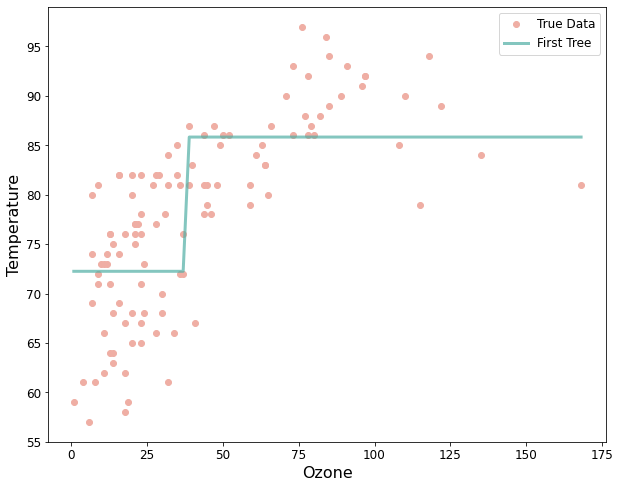

In [133]:
plt.figure(figsize=(10,8))

plt.plot(x,y,'o',color='#EFAEA4', markersize=6, label="True Data")
# plt.plot([x.min(),x.max()],[0,0],'--')
plt.xlim()
plt.plot(x,y_pred,alpha=0.7,linewidth=3,color='#50AEA4', label='First Tree')
plt.xlabel("Ozone", fontsize=16)
plt.ylabel("Temperature", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='best',fontsize=12)
plt.show()

In [134]:
# calculate error residuals

residuals = y - y_pred

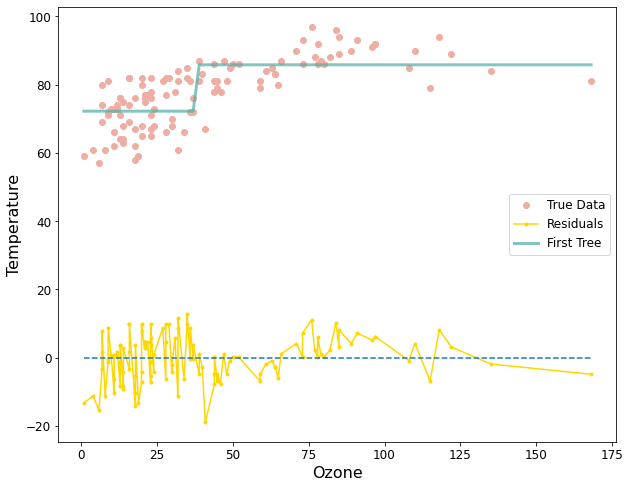

In [135]:
plt.figure(figsize=(10,8))

plt.plot(x,y,'o',color='#EFAEA4', markersize=6, label="True Data")
plt.plot(x,residuals,'.-',color='gold', markersize=6, label="Residuals")
plt.plot([x.min(),x.max()],[0,0],'--')
plt.xlim()
plt.plot(x,y_pred,alpha=0.7,linewidth=3,color='#50AEA4', label='First Tree')
plt.xlabel("Ozone", fontsize=16)
plt.ylabel("Temperature", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='center right',fontsize=12)
plt.show()

In [136]:
### edTest(test_fitted_residuals) ###
dtr = DecisionTreeRegressor(max_depth=1);
dtr.fit(x, residuals)

y_pred_residuals = dtr.predict(x)

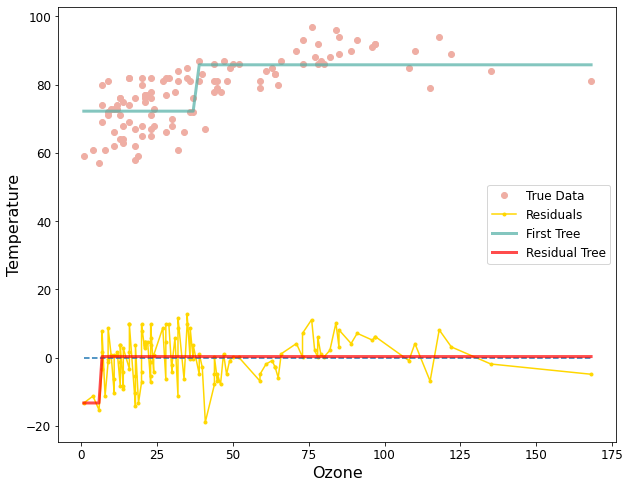

In [137]:
plt.figure(figsize=(10,8))

plt.plot(x,y,'o',color='#EFAEA4', markersize=6, label="True Data")
plt.plot(x,residuals,'.-',color='gold', markersize=6, label="Residuals")
plt.plot([x.min(),x.max()],[0,0],'--')
plt.xlim()
plt.plot(x,y_pred,alpha=0.7,linewidth=3,color='#50AEA4', label='First Tree')
plt.plot(x,y_pred_residuals,alpha=0.7,linewidth=3,color='red', label='Residual Tree')
plt.xlabel("Ozone", fontsize=16)
plt.ylabel("Temperature", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='center right',fontsize=12)
plt.show()

In [138]:
### edTest(test_new_pred) ###
lambda_ = 0.5
y_pred_new = y_pred + lambda_*y_pred_residuals

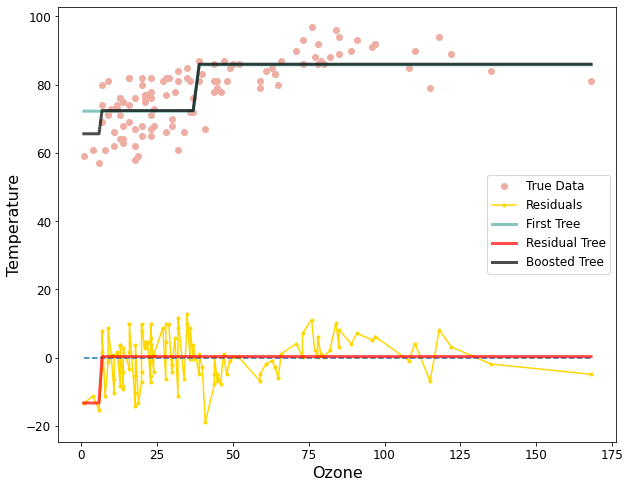

In [139]:
plt.figure(figsize=(10,8))

plt.plot(x,y,'o',color='#EFAEA4', markersize=6, label="True Data")
plt.plot(x,residuals,'.-',color='gold', markersize=6, label="Residuals")
plt.plot([x.min(),x.max()],[0,0],'--')
plt.xlim()
plt.plot(x,y_pred,alpha=0.7,linewidth=3,color='#50AEA4', label='First Tree')
plt.plot(x,y_pred_residuals,alpha=0.7,linewidth=3,color='red', label='Residual Tree')
plt.plot(x,y_pred_new,alpha=0.7,linewidth=3,color='k', label='Boosted Tree')
plt.xlabel("Ozone", fontsize=16)
plt.ylabel("Temperature", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='center right',fontsize=12)
plt.show()

In [150]:
boosted_model  = GradientBoostingRegressor(n_estimators=1000,max_depth=2)

boosted_model.fit(x,y)

y_pred = boosted_model.predict(x)

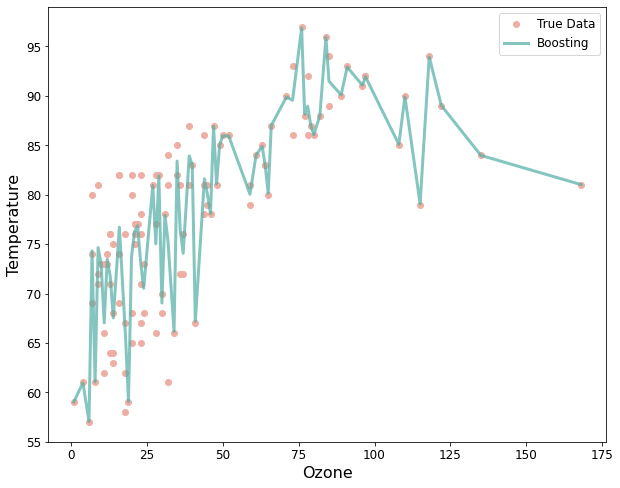

In [151]:
plt.figure(figsize=(10,8))

plt.plot(x,y,'o',color='#EFAEA4', markersize=6, label="True Data")
plt.xlim()
plt.plot(x,y_pred,alpha=0.7,linewidth=3,color='#50AEA4', label='Boosting')
plt.xlabel("Ozone", fontsize=16)
plt.ylabel("Temperature", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='best',fontsize=12)
plt.show()

In [152]:
# Specify the number of bootstraps
num_bootstraps = 30

# Specify the maximum depth of the decision tree
max_depth = 100

# Define the Bagging Regressor Model
# Use Decision Tree as your base estimator with depth as mentioned in max_depth
# Initialise number of estimators using the num_bootstraps value
# Set bootstrap_features and max_samples as 0.8
model = BaggingRegressor(DecisionTreeRegressor(max_depth=max_depth),
                         n_estimators=num_bootstraps)
                        

# Fit the model on the entire data
model.fit(x, y)

BaggingRegressor(base_estimator=DecisionTreeRegressor(max_depth=100),
                 n_estimators=30)

In [153]:
# Compute the MSE of the model prediction

print("The MSE of the Boosting model is",round(mean_squared_error(y,boosted_model.predict(x)),3))

The MSE of the Boosting model is 14.962


In [154]:
# Compute the MSE of the model prediction

print("The MSE of the Bagging model is",round(mean_squared_error(y,model.predict(x)),3))

The MSE of the Bagging model is 17.534
